In [1]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import r2_score
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter, NullFormatter
from matplotlib.lines import Line2D
import pandas as pd
from numpy import log10 as log
import matplotlib.colors as mcolors
import geopandas as gpd
import sys
from pathlib import Path
PROJECT_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "Scripts").is_dir()
)
scripts_directory = PROJECT_ROOT / 'Scripts' / 'Helpers'

# Convert the Path object to a string and append it to sys.path
if str(scripts_directory) not in sys.path:
    sys.path.append(str(scripts_directory))
from Helpers import *

In [2]:
cols = ["MSA",
    "Intellectual Property Law_binary_count",       
    "Immigration Law_binary_count",                
    "Corporate / Business Law_binary_count",        
    "Tax Law_binary_count",                        
    "Employment / Labor Law_binary_count",          
    "Civil Litigation_binary_count",               
    "Personal Injury / Torts_binary_count",         
    "Bankruptcy Law_binary_count",                  
    "total_unique_lawyers",            
    "Real Estate Law_binary_count",                 
    "Criminal Defense_binary_count",                
    "Family Law_binary_count",                     
    "Estate Planning / Probate / Trusts_binary_count",'B01003_001E', 'land_area_sqmi'
]
df = pd.read_csv(PROJECT_ROOT/"Data/BrightData_Lawyers/BrightData_Lawyers_master.csv")
df.rename(columns={"n_lawyers": "total_unique_lawyers"}, inplace=True)
df["MSA Code"] = (pd.to_numeric(df["CBSA"], errors="coerce") // 10).astype("Int64")
gdf = gpd.read_file(PROJECT_ROOT/"Data/Geography/CBSA_shapefile_2025/tl_2025_us_cbsa.shp")[["GEOID", "NAMELSAD", "ALAND"]]
gdf = gdf[gdf["NAMELSAD"].str.contains("Metro Area", na=False)]
gdf["MSA Code"] = gdf["GEOID"].str[:-1].astype(int)
gdf["land_area_sqmi"] = gdf["ALAND"] / 2589988.110336
df_bls = pd.read_csv(PROJECT_ROOT/"Data/Population Data/MSA Population/ACSDT1Y2024.B01003-Data.csv")[["GEO_ID", "NAME", "B01003_001E"]]
df_bls = df_bls[df_bls["NAME"].str.contains("Metro Area", na=False)]
df_bls["MSA Code"] = df_bls["GEO_ID"].str[-5:].str[:-1].astype(int)
df = df.merge(df_bls[["MSA Code", "B01003_001E"]], on="MSA Code", how="left")
df = df.merge(gdf[["MSA Code", "land_area_sqmi"]], on="MSA Code", how="left")
df = df[cols]
df[cols[1:]] = df[cols[1:]].apply(pd.to_numeric, errors="coerce")
df = df.dropna()
df["Total"] = df["total_unique_lawyers"]
laws = [
    "Intellectual Property Law_binary_count",       
    "Immigration Law_binary_count",                
    "Corporate / Business Law_binary_count",        
    "Tax Law_binary_count",                        
    "Employment / Labor Law_binary_count",          
    "Civil Litigation_binary_count",               
    "Personal Injury / Torts_binary_count",         
    "Bankruptcy Law_binary_count",                              
    "Real Estate Law_binary_count",                 
    "Criminal Defense_binary_count",                
    "Family Law_binary_count",                     
    "Estate Planning / Probate / Trusts_binary_count",
]

# Sort specialties by ascending Beta_Population
# Same logic as the inference plot

pop_col = "B01003_001E"

beta_pop_order = []

for law in laws:
    df_reg = df[[law, pop_col]].copy()
    df_reg = df_reg[(df_reg[law] > 0) & (df_reg[pop_col] > 0)]

    beta, ci_low, ci_high, r2 = scale(
        df_reg[pop_col].values,
        df_reg[law].values,
        n_perm=1000
    )

    beta_pop_order.append((law, beta))

laws_binary_order_betaP = [
    law for law, beta in sorted(beta_pop_order, key=lambda x: x[1])
]

# IMPORTANT:
# The helper grid functions loop over laws[::-1],
# so pass the reversed sorted list to make the displayed panels ascending.
laws_for_scaling_grids = laws_binary_order_betaP[::-1]

pd.DataFrame({
    "Law": [law.replace("_binary_count", "") for law, beta in beta_pop_order],
    "Beta_Population": [beta for law, beta in beta_pop_order]
}).sort_values("Beta_Population")

,Law,Beta_Population
10,Family Law,1.036821
11,Estate Planning / Probate / Trusts,1.056322
9,Criminal Defense,1.077233
7,Bankruptcy Law,1.179060
6,Personal Injury / Torts,1.180916
8,Real Estate Law,1.187679
5,Civil Litigation,1.242411
4,Employment / Labor Law,1.273193
2,Corporate / Business Law,1.305408
3,Tax Law,1.333901


In [3]:
plt.rcParams.update({
    'axes.titlesize': 20,      # plot titles
    'axes.labelsize': 22,      # x and y labels
    'xtick.labelsize': 22,     # x-axis tick labels
    'ytick.labelsize': 22,     # y-axis tick labels
    'legend.fontsize': 24,
    "font.family":"arial",
    #"font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "mathtext.default": "rm",
    "mathtext.rm"  : "arial",# legend
})

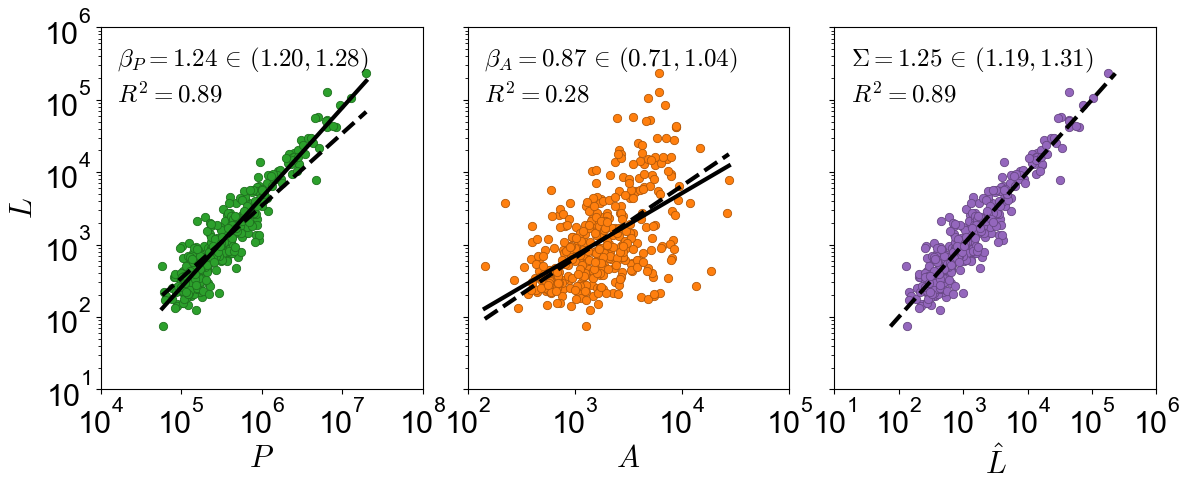

In [4]:
plot_scaling_trip(df, "Total")

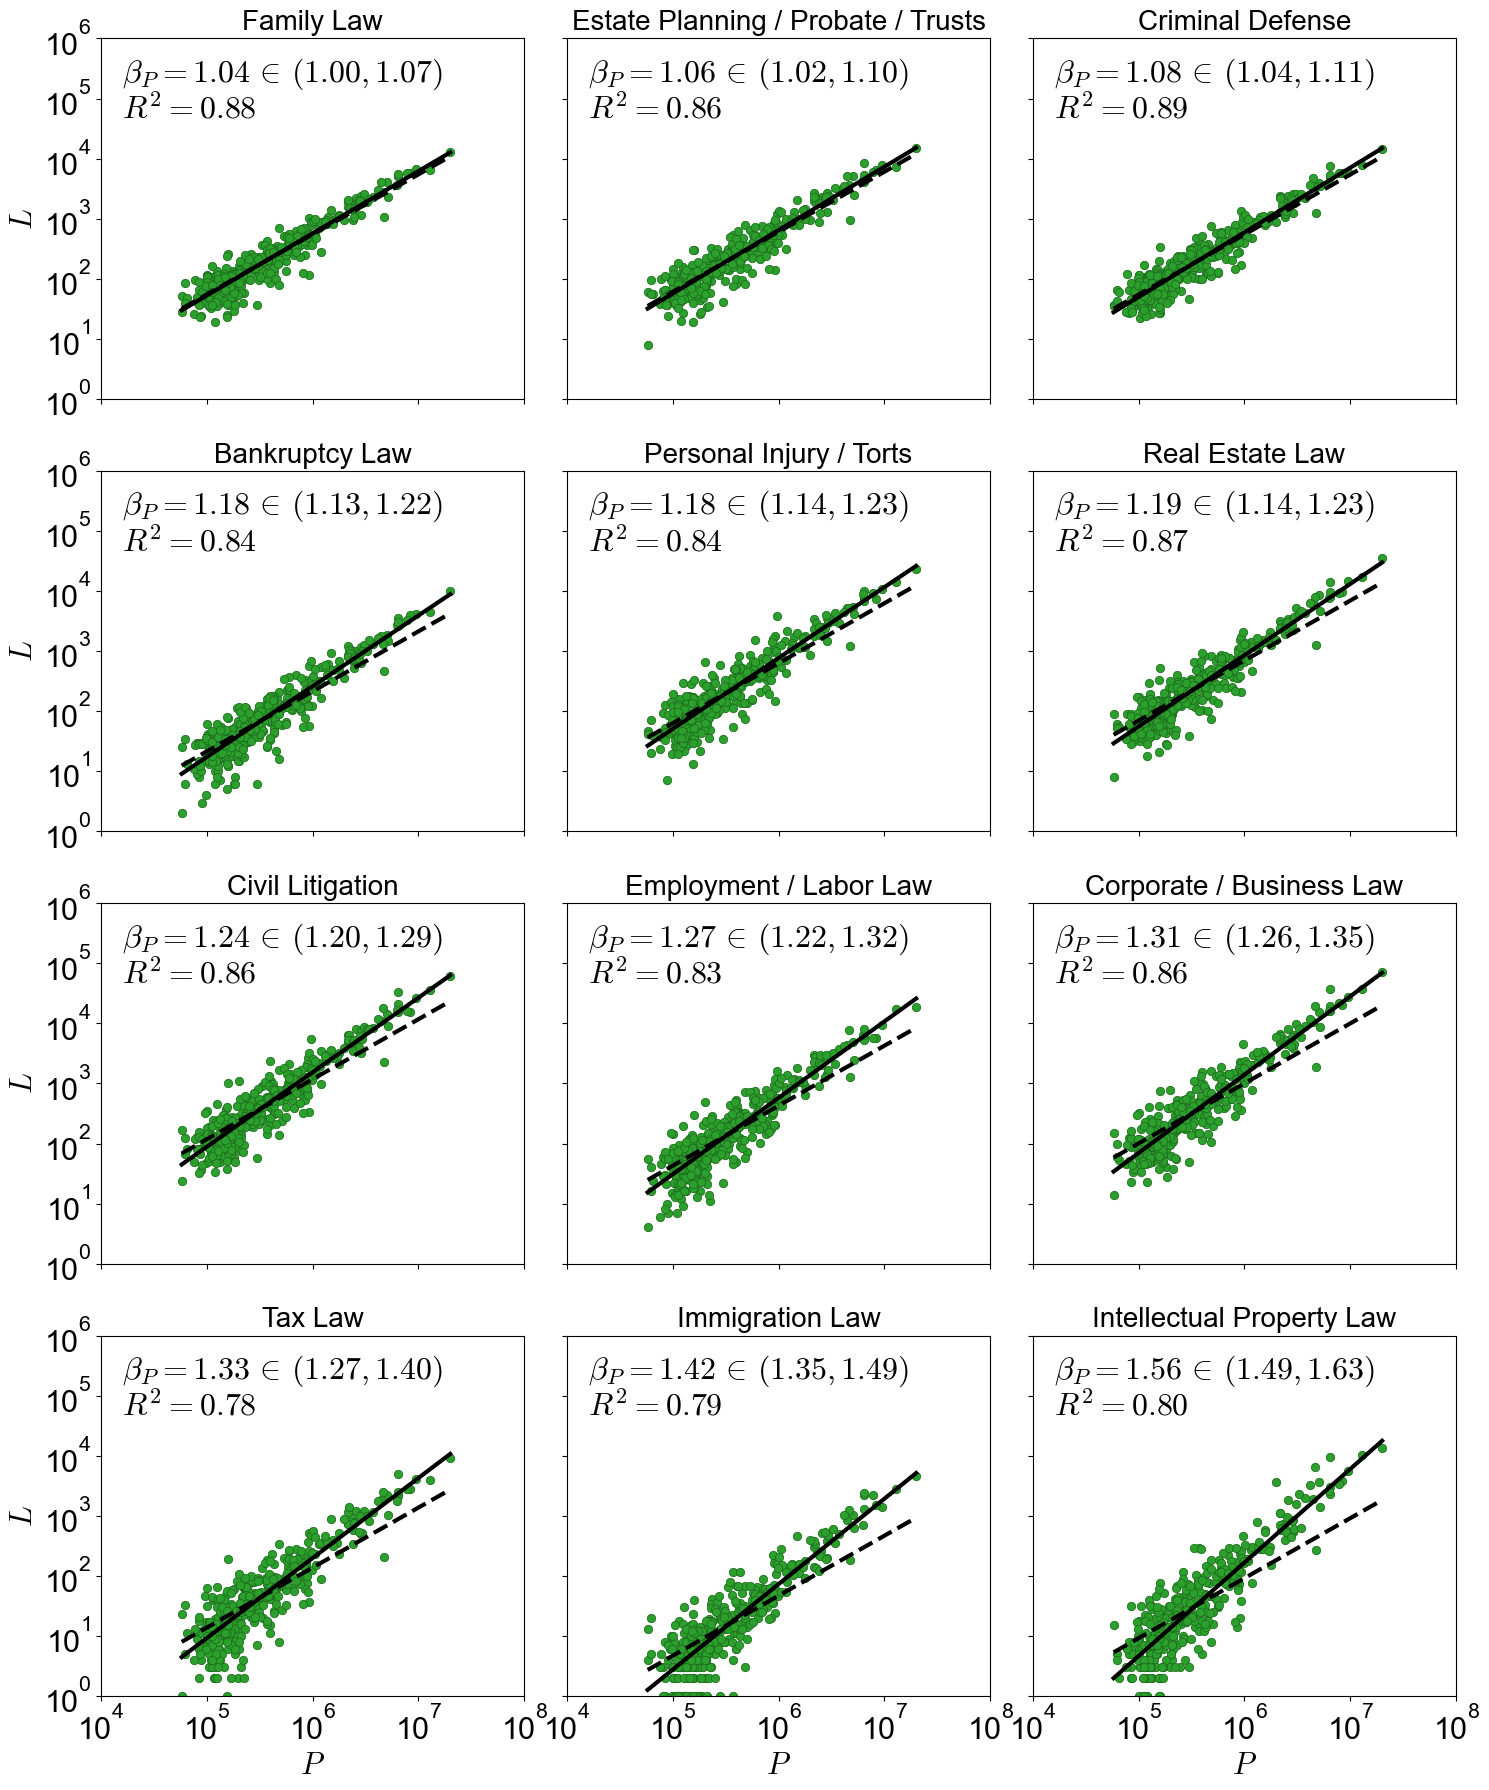

In [5]:
plot_population_scaling_grid(df, laws_for_scaling_grids)

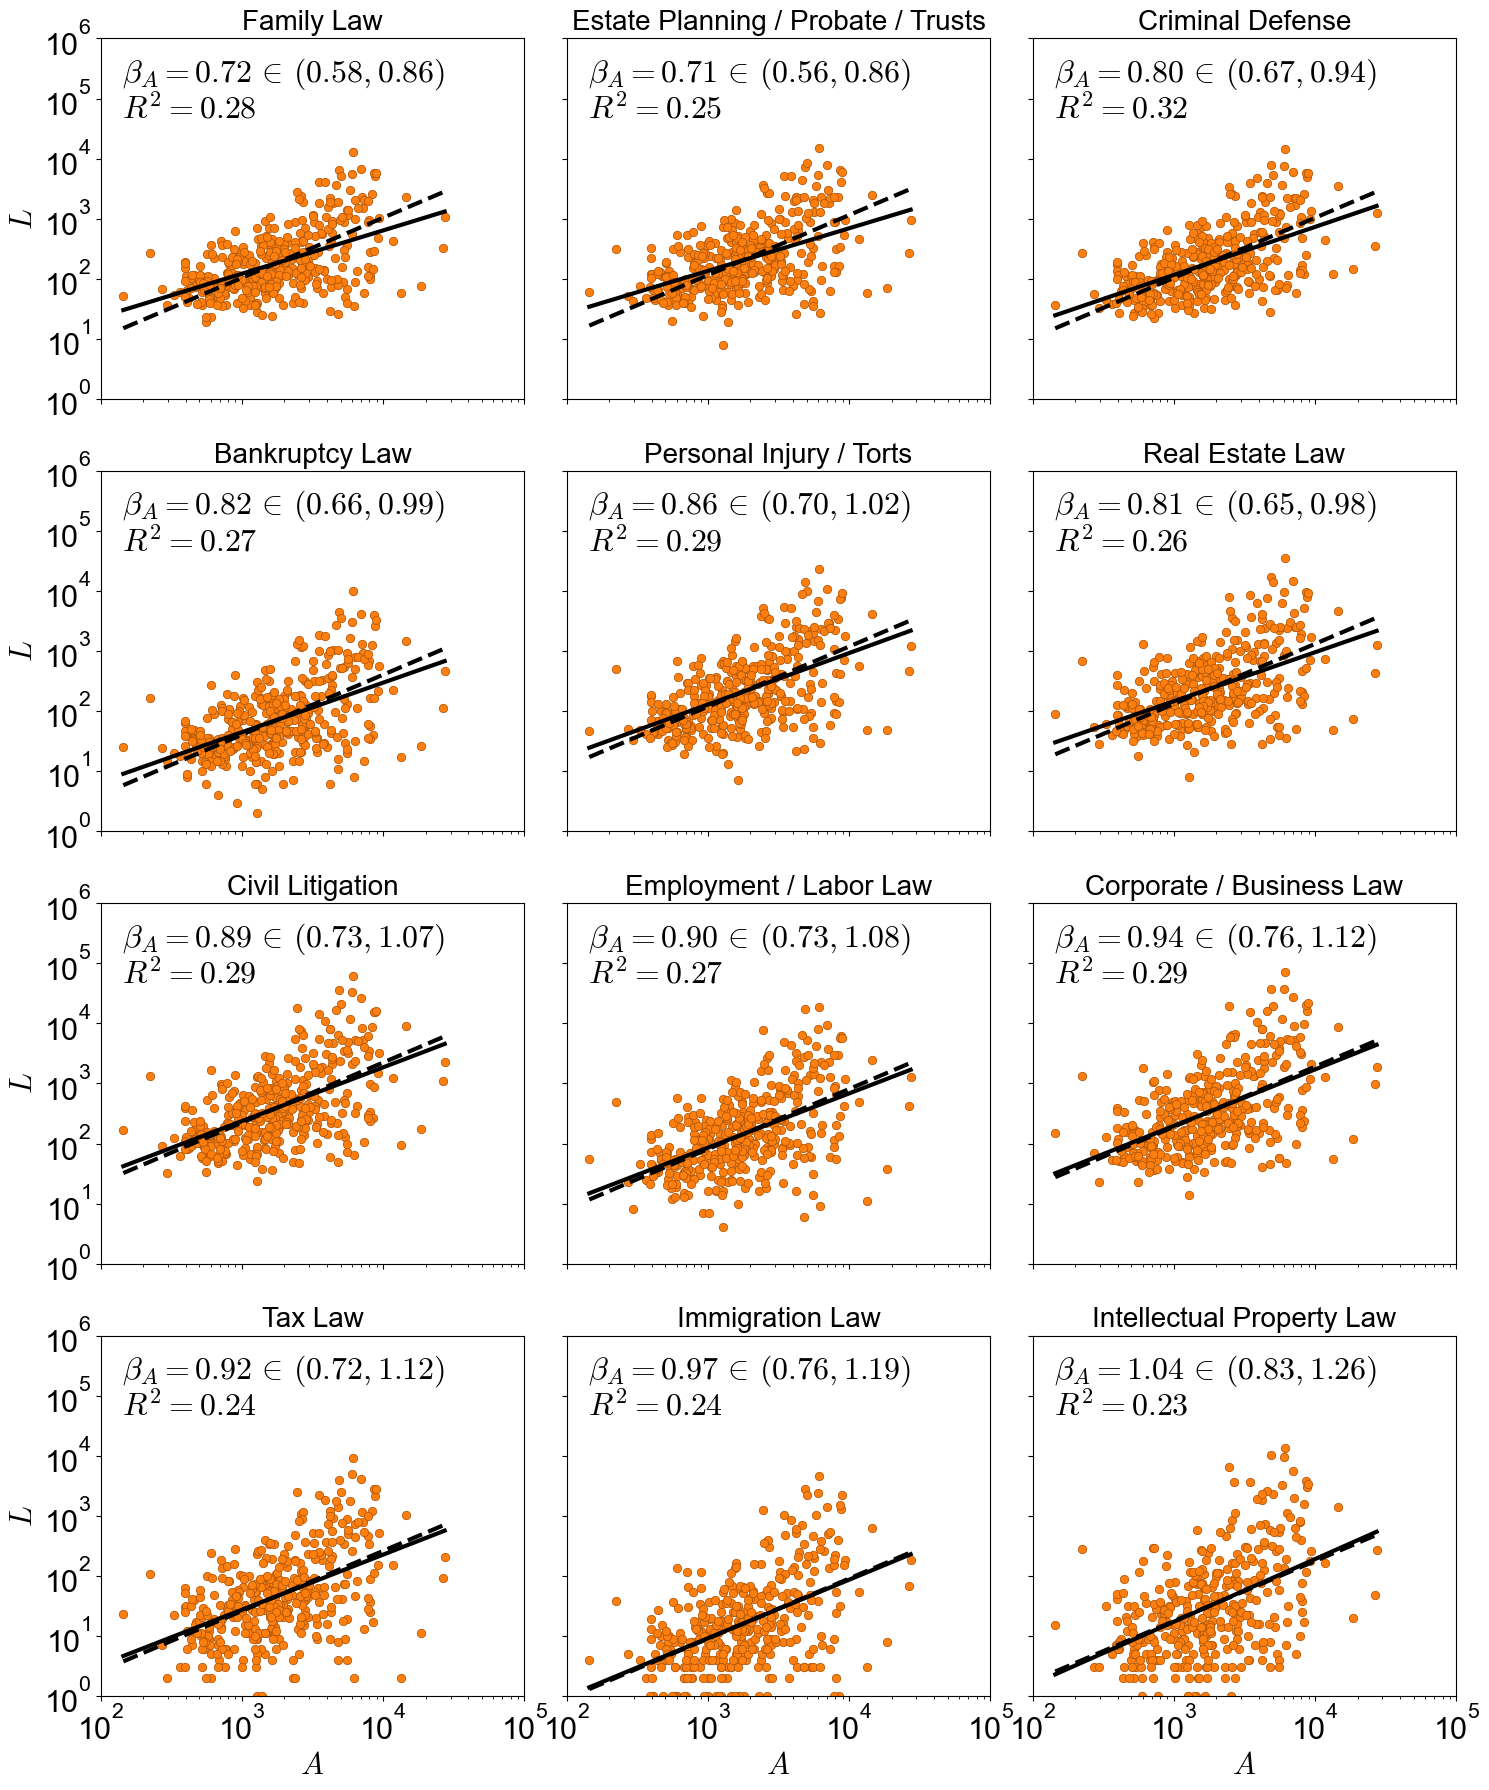

In [6]:
plot_area_scaling_grid(df, laws_for_scaling_grids)

In [7]:
df_IPL = df.copy()
df_IPL = df_IPL[df_IPL["Intellectual Property Law_binary_count"]>0]
scale(df_IPL["land_area_sqmi"].values, df_IPL["Intellectual Property Law_binary_count"].values, 100000)

(1.0434736138673022,
 0.8294638989562947,
 1.2651788754374937,
 0.2310927976767555)

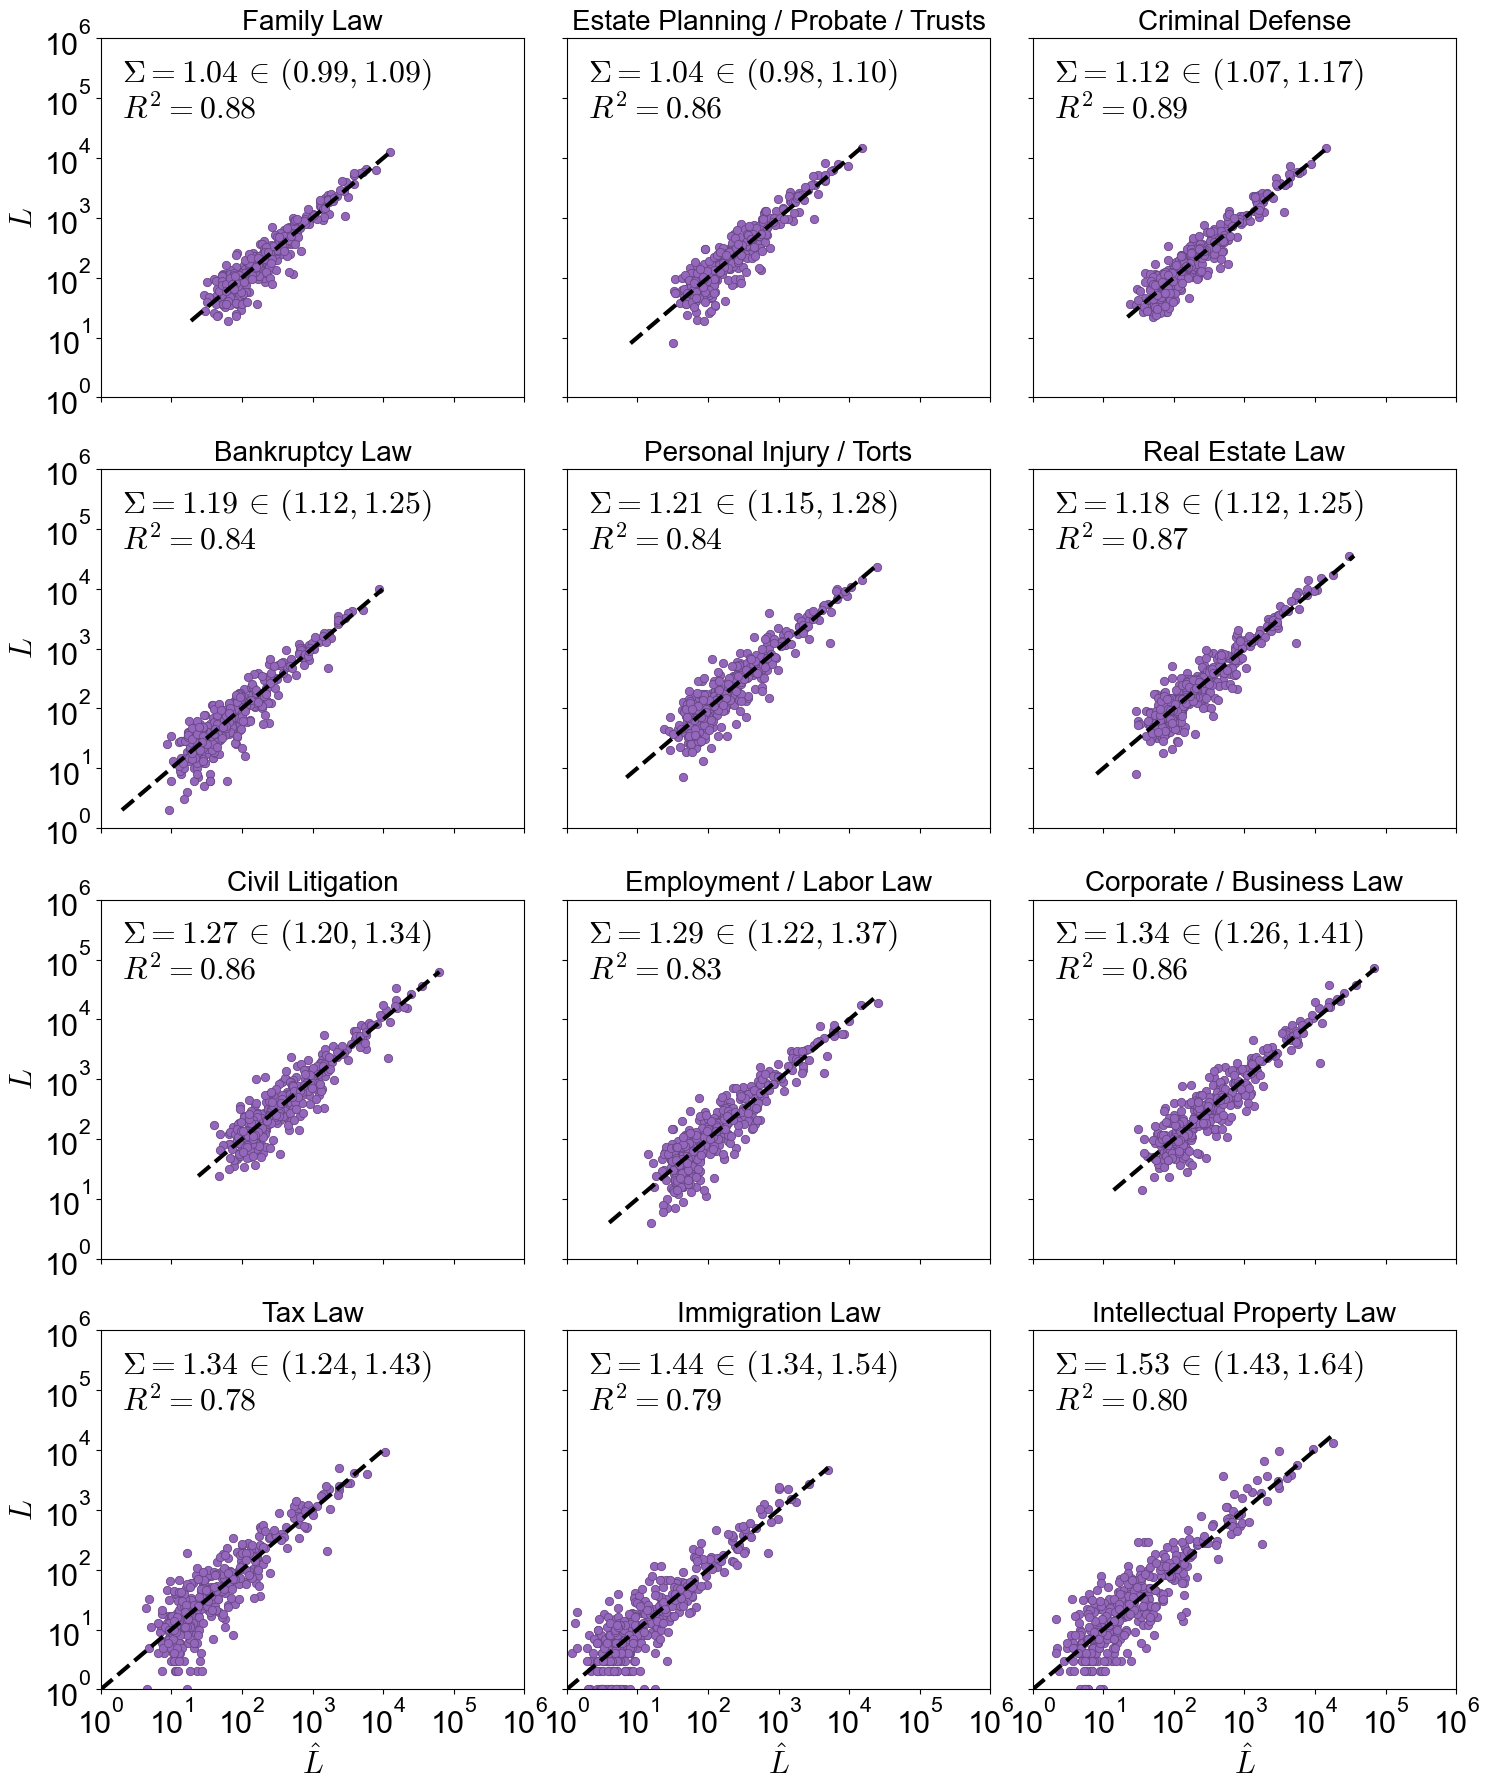

In [8]:
plot_cobb_douglas_grid(df, laws_for_scaling_grids)